In [15]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

from pathlib import Path

output_dir = Path('../public/images')
output_dir.mkdir(parents=False, exist_ok=True)

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('dark_background')

/tmp/ipykernel_150311/3619919255.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_150311/3619919255.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


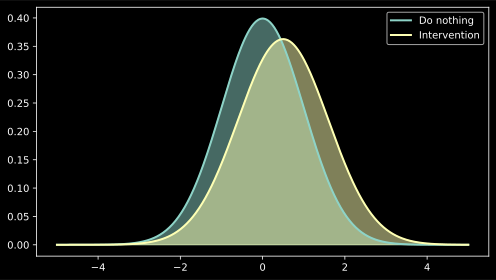

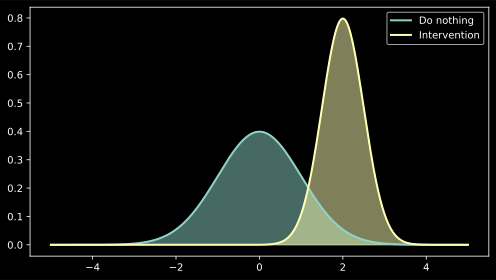

In [48]:
def outcome_plot(ax, y1, y2):
    ax.plot(x, y1, label='Do nothing', lw=2)
    ax.plot(x, y2, label='Intervention', lw=2)
    ax.fill_between(x, y1, color='C0', alpha=0.5)
    ax.fill_between(x, y2, color='C1', alpha=0.5)
    ax.legend()

x = np.linspace(-5, 5, 400)
# First Gaussian: mean=0, std=1
mu1, sigma1 = 0, 1
y1 = (1/(sigma1 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu1)/sigma1)**2)
# Second Gaussian: mean=0.5, std=1.1 (very similar, significant overlap)
mu2, sigma2 = 0.5, 1.1
y2 = (1/(sigma2 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu2)/sigma2)**2)

fig, ax = plt.subplots(figsize=(7, 4))
outcome_plot(ax, y1, y2)
fig.tight_layout()
fig.show()
fig.savefig(output_dir / 'outcome-overlap.svg', format='svg', transparent=True)

mu2, sigma2 = 2, 0.5
y2 = (1/(sigma2 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu2)/sigma2)**2)

fig, ax = plt.subplots(figsize=(7, 4))
outcome_plot(ax, y1, y2)
fig.tight_layout()
fig.show()
fig.savefig(output_dir / 'outcome-separated.svg', format='svg', transparent=True)

/tmp/ipykernel_150311/570583554.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_150311/570583554.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


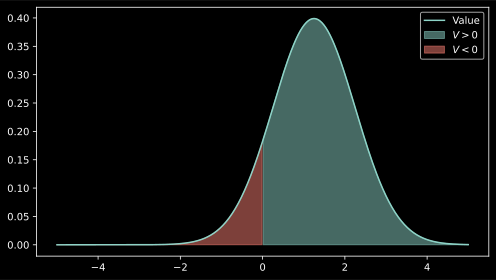

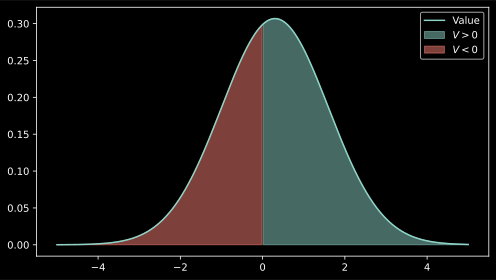

In [55]:
def margin_plot(ax, mu, sigma):
    x = np.linspace(-5, 5, 400)
    y = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)
    ax.plot(x, y, label='Value')
    ax.fill_between(x, y, where=(x > 0), color='C0', alpha=0.5, label='$V>0$')
    ax.fill_between(x, y, where=(x < 0), color='C3', alpha=0.5, label='$V<0$')
    ax.legend()
    return x, y

fig, ax = plt.subplots(figsize=(7, 4))
x, y = margin_plot(ax, mu=1.25, sigma=1.0)
fig.tight_layout()
fig.show()
fig.savefig(output_dir / 'outcome-margin.svg', format='svg', transparent=True)

fig, ax = plt.subplots(figsize=(7, 4))
x, y = margin_plot(ax, mu=0.3, sigma=1.3)
fig.tight_layout()
fig.show()
fig.savefig(output_dir / 'outcome-margin-bad.svg', format='svg', transparent=True)